# 1.0 — Data Loading & Exploration

Download the Construction Site Safety dataset from Roboflow, explore its structure, visualize samples, and analyze class distribution.

**Clean architecture rule:** all data-loading logic lives in `algear.dataset`; this notebook only orchestrates and visualizes.

## Setup

In [1]:
# @title Install dependencies
!pip install -q ultralytics roboflow loguru typer python-dotenv pyyaml matplotlib opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.6 MB/s eta 0:00:00


In [1]:
# @title Mount Google Drive (or clone the repo)
import os
from pathlib import Path
import sys

# Option A: Mount Drive and point to your project folder
# from google.colab import drive
# drive.mount('/content/drive')
# PROJECT_DIR = Path("/content/drive/MyDrive/AlGear")

# Option B: Clone from GitHub instead
!git clone https://github.com/Hndra04/AlGear
PROJECT_DIR = Path("/content/AlGear")

os.chdir(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project root: {PROJECT_DIR}")
print(f"Contents: {list(PROJECT_DIR.iterdir())[:10]}")

fatal: destination path 'AlGear' already exists and is not an empty directory.
Project root: /content/AlGear
Contents: [PosixPath('/content/AlGear/setup.cfg'), PosixPath('/content/AlGear/requirements.txt'), PosixPath('/content/AlGear/LICENSE'), PosixPath('/content/AlGear/models'), PosixPath('/content/AlGear/docs'), PosixPath('/content/AlGear/notebooks'), PosixPath('/content/AlGear/.gitignore'), PosixPath('/content/AlGear/Makefile'), PosixPath('/content/AlGear/pyproject.toml'), PosixPath('/content/AlGear/algear')]


In [2]:
# @title Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = "j6OjTV8xOs6ajAGS9mcN"  # <-- Paste your key here

from algear.config import (
    ROBOFLOW_API_KEY, ROBOFLOW_DIR,
    ROBOFLOW_WORKSPACE, ROBOFLOW_PROJECT, ROBOFLOW_VERSION,
)
print(f"API key set: {bool(ROBOFLOW_API_KEY)}")
print(f"Workspace: {ROBOFLOW_WORKSPACE}, Project: {ROBOFLOW_PROJECT}, v{ROBOFLOW_VERSION}")

2026-06-22 15:29:30.305 | INFO     | algear.config:<module>:10 - PROJ_ROOT path is: /content/AlGear


API key set: True
Workspace: roboflow-100, Project: construction-safety-gsnvb, v1


In [3]:
# @title Download dataset from Roboflow
from algear.dataset import download_roboflow

if not ROBOFLOW_DIR.exists():
    download_roboflow(output_dir=ROBOFLOW_DIR)
else:
    print(f"Dataset already exists at {ROBOFLOW_DIR}")

2026-06-22 15:29:31.263 | INFO     | algear.dataset:download_roboflow:33 - Downloading roboflow-100/construction-safety-gsnvb v1 to /content/AlGear/data/raw/construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/AlGear/data/raw/construction-safety-gsnvb in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 3435.27it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-06-22 15:29:56.820 | SUCCESS  | algear.dataset:download_roboflow:37 - Dataset downloaded to /content/AlGear/data/raw/construction-safety-gsnvb


## 1. Inspect dataset structure

In [4]:
# @title Show directory tree
def show_tree(path: Path, max_depth: int = 2):
    for child in sorted(path.rglob("*")):
        rel = child.relative_to(path)
        depth = len(rel.parts)
        if depth <= max_depth:
            prefix = "  " * depth + "\u2514\u2500 "
            print(f"{prefix}{rel.parts[-1]}{'/' if child.is_dir() else ''}")

show_tree(ROBOFLOW_DIR)

  └─ README.dataset.txt
  └─ README.roboflow.txt
  └─ data.yaml
  └─ test/
    └─ images/
    └─ labels/
  └─ train/
    └─ images/
    └─ labels/
  └─ valid/
    └─ images/
    └─ labels/


In [5]:
# @title Show class names
import yaml

data_yaml = ROBOFLOW_DIR / "data.yaml"
with open(data_yaml) as f:
    cfg = yaml.safe_load(f)

print("Classes:")
for i, name in enumerate(cfg["names"]):
    print(f"  {i}: {name}")

Classes:
  0: helmet
  1: no-helmet
  2: no-vest
  3: person
  4: vest


In [6]:
# @title Count images and labels per split
def count_images_labels(split: str) -> dict:
    img_dir = ROBOFLOW_DIR / split / "images"
    lbl_dir = ROBOFLOW_DIR / split / "labels"
    images = sorted(img_dir.glob("*")) if img_dir.exists() else []
    labels = sorted(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []
    return {"images": len(images), "labels": len(labels), "path": str(img_dir)}

for split in ["train", "valid", "test"]:
    info = count_images_labels(split)
    print(f"{split:>6s}: {info['images']:>4d} images, {info['labels']:>4d} labels")
    print(f"{'':>6s}  {info['path']}")

 train:  997 images,  997 labels
        /content/AlGear/data/raw/construction-safety-gsnvb/train/images
 valid:  119 images,  119 labels
        /content/AlGear/data/raw/construction-safety-gsnvb/valid/images
  test:   90 images,   90 labels
        /content/AlGear/data/raw/construction-safety-gsnvb/test/images


## 2. Visualise sample images with annotations

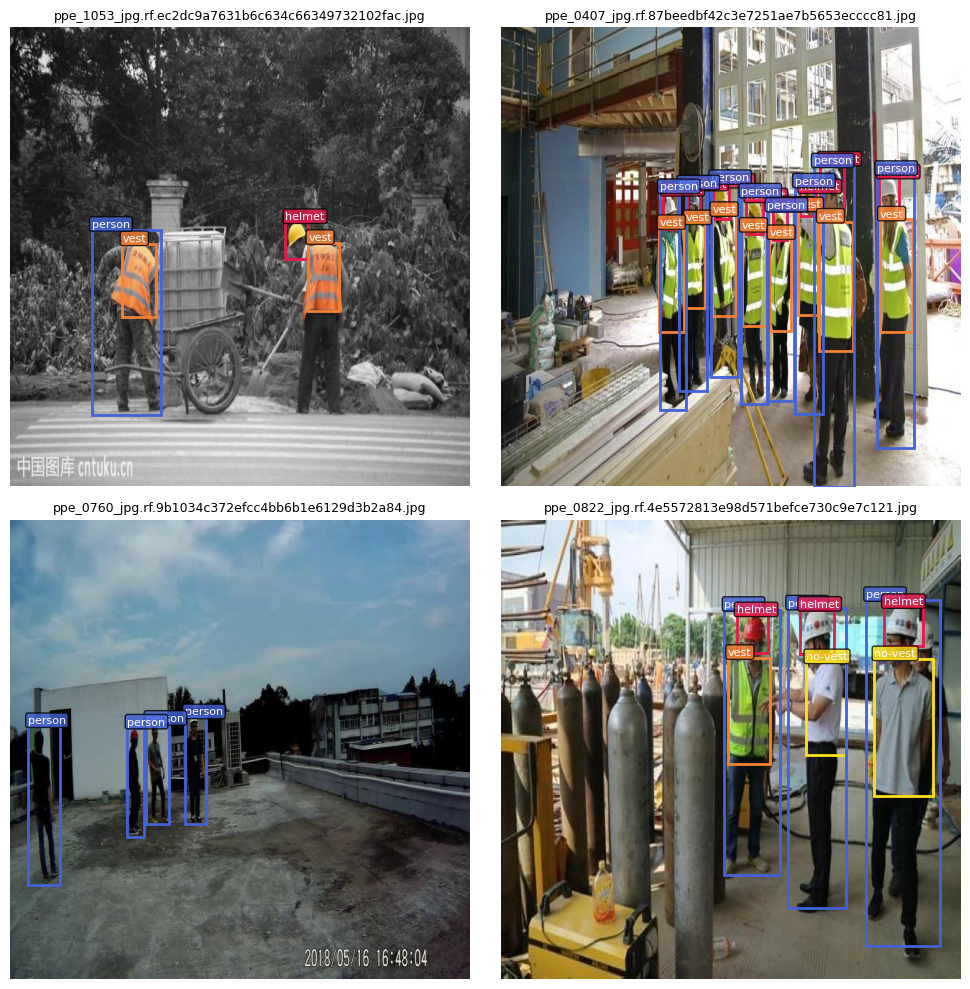

In [7]:
# @title Show random training samples with bounding boxes
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

with open(ROBOFLOW_DIR / "data.yaml") as f:
    class_names = yaml.safe_load(f)["names"]

COLORS = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
    "#911eb4", "#46f0f0", "#f032e6", "#bcf60c", "#fabebe",
]

def show_random_samples(split: str = "train", n: int = 4):
    img_dir = ROBOFLOW_DIR / split / "images"
    lbl_dir = ROBOFLOW_DIR / split / "labels"
    images = sorted(img_dir.glob("*"))
    if not images:
        print(f"No images found in {img_dir}")
        return

    samples = random.sample(images, min(n, len(images)))
    fig, axes = plt.subplots(2, n // 2 if n > 1 else 1, figsize=(5 * (n // 2), 10))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, img_path in zip(axes, samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        ax.imshow(img)

        label_path = lbl_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    cls_id, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    box_w = bw * w
                    box_h = bh * h

                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor=COLORS[cls_id % len(COLORS)],
                        facecolor="none",
                    )
                    ax.add_patch(rect)
                    ax.text(
                        x1, y1 - 4, class_names[cls_id],
                        fontsize=8, color="white",
                        bbox=dict(boxstyle="round,pad=0.2", facecolor=COLORS[cls_id % len(COLORS)], alpha=0.8),
                    )

        ax.set_title(img_path.name, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_random_samples("train", n=4)

## 3. Class distribution analysis

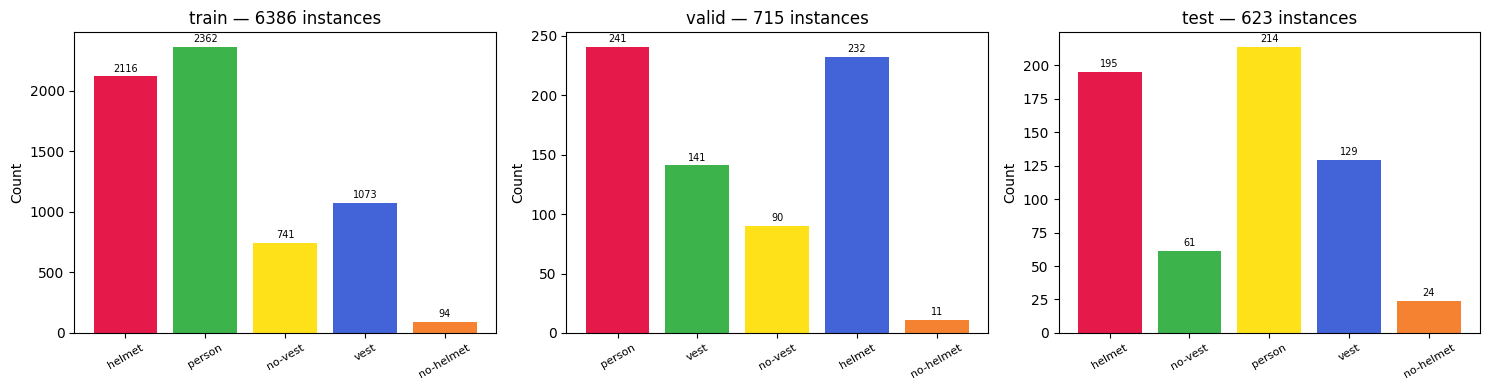

In [8]:
# @title Plot class counts for all splits
from collections import Counter

def class_distribution(split: str) -> Counter:
    lbl_dir = ROBOFLOW_DIR / split / "labels"
    counter = Counter()
    if not lbl_dir.exists():
        return counter
    for label_file in sorted(lbl_dir.glob("*.txt")):
        with open(label_file) as f:
            for line in f:
                cls_id = int(line.strip().split()[0])
                counter[class_names[cls_id]] += 1
    return counter


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, ["train", "valid", "test"]):
    dist = class_distribution(split)
    if dist:
        classes = list(dist.keys())
        counts = list(dist.values())
        bars = ax.bar(classes, counts, color=COLORS[:len(classes)])
        ax.set_title(f"{split} — {sum(counts)} instances")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        for bar, c in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.01,
                    str(c), ha="center", va="bottom", fontsize=7)
    else:
        ax.set_title(f"{split} — no labels")

plt.tight_layout()
plt.show()

## 4. Summary

**Classes**: helmet (0), no-helmet (1), no-vest (2), person (3), vest (4)

| Split   | Images |
|---------|--------|
| Train   | 997    |
| Valid   | 119    |
| Test    | 90     |

**Imbalance watch**: `no-helmet` (94 instances) and `no-vest` (741 instances) are minority classes — see `notebooks/2.1-alg-oversampling.ipynb` for mitigation.